In [7]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

def cross_validate_BLR(data: pd.DataFrame, feature_name: str, kernel_params_grid: dict, 
                       sigma2: float = 0.1, alpha2: float = 1.0, cv: int = 5):
    """
    Realiza validación cruzada para ajustar hiperparámetros del modelo BLR.
    
    Parámetros:
      - data: DataFrame con los datos (se espera que tenga columnas 'age', group, etc.)
      - feature_name: nombre de la columna a predecir (IDP)
      - kernel_params_grid: diccionario con listas de valores candidatos para:
          * "number_of_bases"
          * "length_scale"
          * "bases_sampling_method" (ej. ["KMeans", "Random"])
      - sigma2 y alpha2: valores iniciales para los hiperparámetros del BLR
      - cv: número de folds para KFold
      
    Retorna:
      - best_params: tupla con la mejor combinación (n_bases, length_scale, bases_sampling_method)
      - best_score: el valor de la métrica (MSE) más bajo
    """
    # Filtramos datos del grupo HC
    subset = data[data.group == 'HC']
    X = subset['age'].values.reshape(-1, 1)
    y = subset[feature_name].values

    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    best_score = np.inf
    best_params = None

    # Iterar sobre cada combinación de hiperparámetros
    for n_bases in kernel_params_grid['number_of_bases']:
        for length_scale in kernel_params_grid['length_scale']:
            for bases_sampling_method in kernel_params_grid['bases_sampling_method']:
                scores = []
                kernel_params = {
                    "number_of_bases": n_bases,
                    "length_scale": length_scale,
                    "bases_sampling_method": bases_sampling_method,
                }
                # Validación cruzada
                for train_index, val_index in kf.split(X):
                    X_train, X_val = X[train_index], X[val_index]
                    y_train, y_val = y[train_index], y[val_index]
                    
                    # Crear y ajustar el modelo
                    model = BayesianLinearRegression(kernel_params, sigma2, alpha2)
                    model.fit(X_train, y_train)
                    # Opcional: podrías optimizar sigma2 y alpha2 en cada fold
                    # model.optimize_hyperparameters()
                    
                    # Predecir en el conjunto de validación
                    y_pred, _, _, _, _, _, _ = model.predict_with_samples(X_val)
                    
                    # Calcular MSE
                    score = mean_squared_error(y_val, y_pred)
                    scores.append(score)
                
                avg_score = np.mean(scores)
                print(f"Params: n_bases={n_bases}, length_scale={length_scale}, method={bases_sampling_method} | Score (MSE): {avg_score:.4f}")
                if avg_score < best_score:
                    best_score = avg_score
                    best_params = (n_bases, length_scale, bases_sampling_method)
                    
    return best_params, best_score

# Ejemplo de cómo definir el grid:
kernel_params_grid = {
    "number_of_bases": [10, 20, 30, 40, 50, 60, 80, 100],
    "length_scale": [0.1, 0.5,0.8, 1.0, 2.0],
    "bases_sampling_method": ["KMeans", "Random"],
}

# Llamada al cross validation:
best_params, best_score = cross_validate_BLR(data_roi, "IAFp_PO", kernel_params_grid, cv=5)
print("Mejores hiperparámetros:", best_params)
print("Mejor Score (MSE):", best_score)


Params: n_bases=10, length_scale=0.1, method=KMeans | Score (MSE): 0.8456
Params: n_bases=10, length_scale=0.1, method=Random | Score (MSE): 0.8723
Params: n_bases=10, length_scale=0.5, method=KMeans | Score (MSE): 0.8259
Params: n_bases=10, length_scale=0.5, method=Random | Score (MSE): 0.8273
Params: n_bases=10, length_scale=0.8, method=KMeans | Score (MSE): 0.8249
Params: n_bases=10, length_scale=0.8, method=Random | Score (MSE): 0.8272
Params: n_bases=10, length_scale=1.0, method=KMeans | Score (MSE): 0.8254
Params: n_bases=10, length_scale=1.0, method=Random | Score (MSE): 0.8263
Params: n_bases=10, length_scale=2.0, method=KMeans | Score (MSE): 0.8235
Params: n_bases=10, length_scale=2.0, method=Random | Score (MSE): 0.8236
Params: n_bases=20, length_scale=0.1, method=KMeans | Score (MSE): 0.8351
Params: n_bases=20, length_scale=0.1, method=Random | Score (MSE): 0.8487
Params: n_bases=20, length_scale=0.5, method=KMeans | Score (MSE): 0.8259
Params: n_bases=20, length_scale=0.5, 

d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (72) found smaller than n_clusters (80). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (73) found smaller than n_clusters (80). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (71) found smaller than n_clusters (80). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (72) found smaller than n_clusters (80). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\f

Params: n_bases=80, length_scale=0.1, method=KMeans | Score (MSE): 0.8522
Params: n_bases=80, length_scale=0.1, method=Random | Score (MSE): 0.8508


d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (72) found smaller than n_clusters (80). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (73) found smaller than n_clusters (80). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (71) found smaller than n_clusters (80). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (72) found smaller than n_clusters (80). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\f

Params: n_bases=80, length_scale=0.5, method=KMeans | Score (MSE): 0.8264
Params: n_bases=80, length_scale=0.5, method=Random | Score (MSE): 0.8266


...

Params: n_bases=100, length_scale=0.8, method=KMeans | Score (MSE): 0.8248
Params: n_bases=100, length_scale=0.8, method=Random | Score (MSE): 0.8246


d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (72) found smaller than n_clusters (100). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (73) found smaller than n_clusters (100). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (71) found smaller than n_clusters (100). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (72) found smaller than n_clusters (100). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Params: n_bases=100, length_scale=1.0, method=KMeans | Score (MSE): 0.8249
Params: n_bases=100, length_scale=1.0, method=Random | Score (MSE): 0.8252


d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (72) found smaller than n_clusters (100). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (73) found smaller than n_clusters (100). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (71) found smaller than n_clusters (100). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (72) found smaller than n_clusters (100). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Params: n_bases=100, length_scale=2.0, method=KMeans | Score (MSE): 0.8242
Params: n_bases=100, length_scale=2.0, method=Random | Score (MSE): 0.8241
Mejores hiperparámetros: (10, 2.0, 'KMeans')
Mejor Score (MSE): 0.8234698379642239


In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
import math
import matplotlib.pyplot as plt

def cross_validate_BLR_msll(data: pd.DataFrame, feature_name: str, kernel_params_grid: dict, 
                            sigma2: float = 0.1, alpha2: float = 1.0, cv: int = 5):
    """
    Realiza validación cruzada para ajustar los hiperparámetros del kernel (número de bases,
    length_scale y método de sampling) usando MSLL como métrica.

    Parámetros:
      - data: DataFrame con los datos. Se espera que tenga columnas 'age', 'group', etc.
      - feature_name: nombre de la columna objetivo (por ejemplo, un IDP)
      - kernel_params_grid: diccionario con listas de valores candidatos para:
          * "number_of_bases"
          * "length_scale"
          * "bases_sampling_method" (por ejemplo, ["KMeans", "Random"])
      - sigma2, alpha2: hiperparámetros fijos iniciales para el BLR (podrías optimizarlos aparte)
      - cv: número de folds para la validación cruzada
      
    Retorna:
      - best_params: tuple con la mejor combinación (n_bases, length_scale, bases_sampling_method)
      - best_score: el valor MSLL promedio más bajo
    """
    # Filtra los datos para el grupo de interés (por ejemplo, HC)
    subset = data[data.group == 'HC']
    X = subset['age'].values.reshape(-1, 1)
    y = subset[feature_name].values

    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    best_score = np.inf
    best_params = None

    # Explora todas las combinaciones en el grid
    for n_bases in kernel_params_grid['number_of_bases']:
        for length_scale in kernel_params_grid['length_scale']:
            for bases_sampling_method in kernel_params_grid['bases_sampling_method']:
                scores = []
                kernel_params = {
                    "number_of_bases": n_bases,
                    "length_scale": length_scale,
                    "bases_sampling_method": bases_sampling_method,
                }
                # Validez cruzada en cv folds
                for train_index, val_index in kf.split(X):
                    X_train, X_val = X[train_index], X[val_index]
                    y_train, y_val = y[train_index], y[val_index]
                    
                    # Crea y entrena el modelo
                    model = BayesianLinearRegression(kernel_params, sigma2, alpha2)
                    model.fit(X_train, y_train)
                    # Opcional: puedes optimizar sigma2 y alpha2 en cada fold
                    # model.optimize_hyperparameters()
                    
                    # Obtén las predicciones; 
                    # Se espera que predict_with_samples retorne:
                    # (y_mean_original_scale, y_std_original_scale, y_samples_original_scale, ci_lower, ci_upper, pi_lower, pi_upper)
                    y_pred, pred_std, _, _, _, _, _ = model.predict_with_samples(X_val)
                    
                    # Calcula el MSLL para este fold
                    score = compute_MSLL(y_val, y_pred, pred_std)
                    scores.append(score)
                
                avg_score = np.mean(scores)
                print(f"Params: n_bases={n_bases}, length_scale={length_scale}, method={bases_sampling_method} | MSLL: {avg_score:.4f}")
                if avg_score < best_score:
                    best_score = avg_score
                    best_params = (n_bases, length_scale, bases_sampling_method)
                    
    return best_params, best_score

# Ejemplo de cómo definir el grid de hiperparámetros:
kernel_params_grid = {
    "number_of_bases": [10, 20, 30, 40, 50,60,80,100],
    "length_scale": [0.1, 0.5, 1.0, 2.0, 5.0],
    "bases_sampling_method": ["KMeans", "Random"],
}

# Llamada al cross validation (asegúrate de tener el DataFrame 'data' y reemplaza "nombre_de_tu_feature" por el nombre real):
best_params, best_score = cross_validate_BLR_msll(data_roi, "IAFp_PO", kernel_params_grid, cv=5)
print("Mejores hiperparámetros:", best_params)
print("Mejor MSLL:", best_score)


Params: n_bases=10, length_scale=0.1, method=KMeans | MSLL: 14.8845
Params: n_bases=10, length_scale=0.1, method=Random | MSLL: 18.5264
Params: n_bases=10, length_scale=0.5, method=KMeans | MSLL: 14.6322
Params: n_bases=10, length_scale=0.5, method=Random | MSLL: 15.6993
Params: n_bases=10, length_scale=1.0, method=KMeans | MSLL: 19.8330
Params: n_bases=10, length_scale=1.0, method=Random | MSLL: 20.2673
Params: n_bases=10, length_scale=2.0, method=KMeans | MSLL: 24.2566
Params: n_bases=10, length_scale=2.0, method=Random | MSLL: 24.5200
Params: n_bases=10, length_scale=5.0, method=KMeans | MSLL: 27.9269
Params: n_bases=10, length_scale=5.0, method=Random | MSLL: 26.6645
Params: n_bases=20, length_scale=0.1, method=KMeans | MSLL: 9.2679
Params: n_bases=20, length_scale=0.1, method=Random | MSLL: 11.4173
Params: n_bases=20, length_scale=0.5, method=KMeans | MSLL: 14.7023
Params: n_bases=20, length_scale=0.5, method=Random | MSLL: 14.6837
Params: n_bases=20, length_scale=1.0, method=KMea

d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (72) found smaller than n_clusters (80). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (73) found smaller than n_clusters (80). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (71) found smaller than n_clusters (80). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (72) found smaller than n_clusters (80). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\f

Params: n_bases=80, length_scale=0.1, method=KMeans | MSLL: 7.1457
Params: n_bases=80, length_scale=0.1, method=Random | MSLL: 7.2935


d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (72) found smaller than n_clusters (80). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (73) found smaller than n_clusters (80). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (71) found smaller than n_clusters (80). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (72) found smaller than n_clusters (80). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\f

Params: n_bases=80, length_scale=0.5, method=KMeans | MSLL: 14.0131
Params: n_bases=80, length_scale=0.5, method=Random | MSLL: 14.1243


...

Params: n_bases=100, length_scale=1.0, method=KMeans | MSLL: 18.3975
Params: n_bases=100, length_scale=1.0, method=Random | MSLL: 18.4932


d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (72) found smaller than n_clusters (100). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (73) found smaller than n_clusters (100). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (71) found smaller than n_clusters (100). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (72) found smaller than n_clusters (100). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Params: n_bases=100, length_scale=2.0, method=KMeans | MSLL: 22.8894
Params: n_bases=100, length_scale=2.0, method=Random | MSLL: 23.5768


d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (72) found smaller than n_clusters (100). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (73) found smaller than n_clusters (100). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (71) found smaller than n_clusters (100). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\flujo_portables\env_portables\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (72) found smaller than n_clusters (100). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Params: n_bases=100, length_scale=5.0, method=KMeans | MSLL: 27.1500
Params: n_bases=100, length_scale=5.0, method=Random | MSLL: 26.4933
Mejores hiperparámetros: (80, 0.1, 'KMeans')
Mejor MSLL: 7.145664311820528


## Harmonize

In [11]:
test_harmonize= pd.read_csv(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\AIF_Babiloni\results_harmonize\neuroharmonize\neuroharmonize_abs_a1_O1_age_canonic.csv")
print(test_harmonize.columns)

Index(['subject', 'group', 'SITE', 'IAFp_O1', 'age', 'r2_O1', 'error_O1',
       'CF_extalpha_O1', 'pw_ab_canonic_delta_O1', 'pw_ab_canonic_theta_O1',
       'pw_ab_canonic_alpha1_O1', 'pw_ab_canonic_alpha2_O1',
       'pw_ab_canonic_beta1_O1', 'pw_ab_canonic_beta2_O1',
       'pw_ab_canonic_beta3_O1', 'pw_ab_canonic_gamma_O1', 'TF_O1',
       'harmonized-pca-one', 'harmonized-pca-two', 'harmonized-umap-one',
       'harmonized-umap-two'],
      dtype='object')


Optimized sigma2 for pw_ab_canonic_delta_O1: 0.99950
Optimized alpha2 for pw_ab_canonic_delta_O1: 9999.99983


d:\flujo_portables\NormativeModel_EEG\models\BLR.py:135: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  posterior_weights = np.random.multivariate_normal(mean=np.asarray(self.m).flatten(), cov=self.V_n, size=n_samples)


Optimized sigma2 for pw_ab_canonic_theta_O1: 0.94046
Optimized alpha2 for pw_ab_canonic_theta_O1: 13.79884
Optimized sigma2 for pw_ab_canonic_alpha1_O1: 0.98696
Optimized alpha2 for pw_ab_canonic_alpha1_O1: 115.59534
Optimized sigma2 for pw_ab_canonic_alpha2_O1: 0.92731
Optimized alpha2 for pw_ab_canonic_alpha2_O1: 15.15267
Optimized sigma2 for pw_ab_canonic_beta1_O1: 0.93690
Optimized alpha2 for pw_ab_canonic_beta1_O1: 21.30237
Optimized sigma2 for pw_ab_canonic_beta2_O1: 0.97478
Optimized alpha2 for pw_ab_canonic_beta2_O1: 24.61409
Optimized sigma2 for pw_ab_canonic_beta3_O1: 0.91761
Optimized alpha2 for pw_ab_canonic_beta3_O1: 17.77259
Optimized sigma2 for pw_ab_canonic_gamma_O1: 0.91785
Optimized alpha2 for pw_ab_canonic_gamma_O1: 21.39368


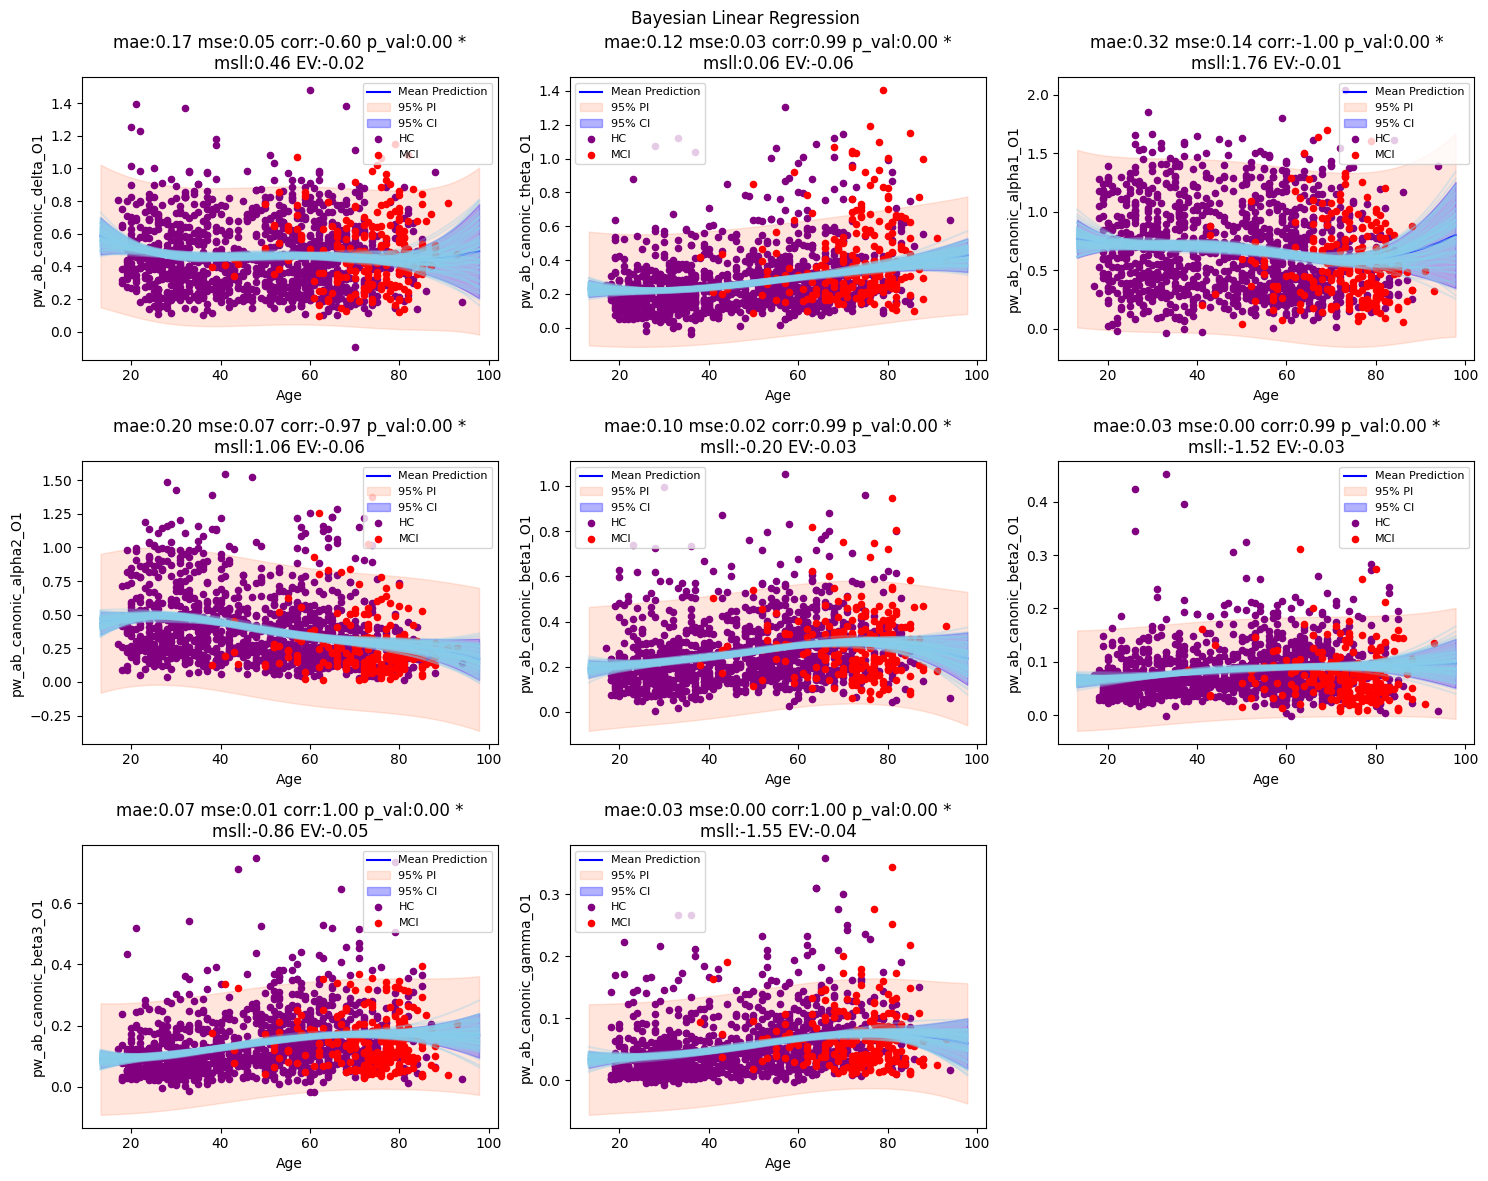

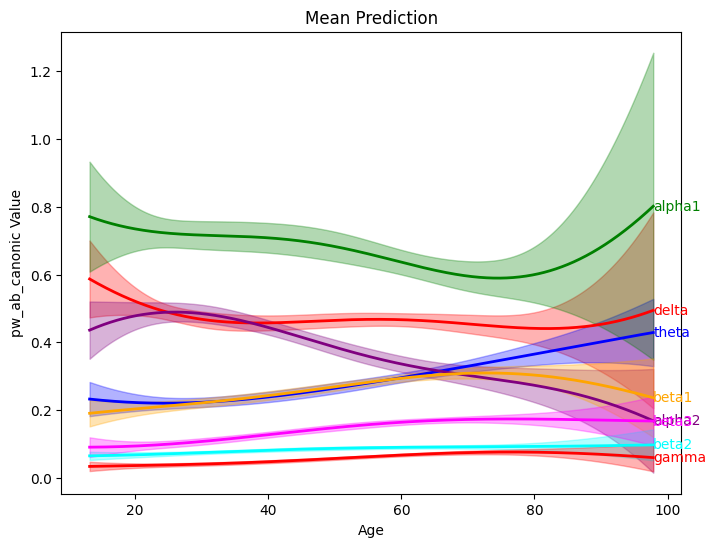

In [16]:

compute_BLR(test_harmonize, {'pw_ab_canonic':['pw_ab_canonic_delta_O1', 'pw_ab_canonic_theta_O1',
       'pw_ab_canonic_alpha1_O1', 'pw_ab_canonic_alpha2_O1',
       'pw_ab_canonic_beta1_O1', 'pw_ab_canonic_beta2_O1',
       'pw_ab_canonic_beta3_O1', 'pw_ab_canonic_gamma_O1']}, 'O1')

In [26]:
from sklearn.preprocessing import OneHotEncoder
def prepare_covariates(df, covariates):
    df = df.copy()
    encoder = OneHotEncoder(sparse_output=False, drop='first')
    cols = []
    if 'SITE' in covariates:
        site_encoded = encoder.fit_transform(df[['SITE']])
        site_df = pd.DataFrame(site_encoded, columns=encoder.get_feature_names_out(['SITE']))
        df = pd.concat([df.reset_index(drop=True), site_df.reset_index(drop=True)], axis=1)
    if 'age' in covariates:
        cols.append('age')
    if 'sex' in covariates:
        df['sex'] = df['sex'].map({'M': 0, 'F': 1})
        cols.append('sex')
    if 'SITE' in covariates:
        cols.extend(site_df.columns.tolist())
    return df[cols].values

In [37]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from models.BLR import BayesianLinearRegression
from models.model_metrics import compute_MSLL, explained_var
from scipy.stats import spearmanr


def compute_BLR_and_save_outputs(df, feature, covset, bases, length_scale, sigma2, alpha2, save_path):
    os.makedirs(save_path, exist_ok=True)

    # Separar por grupo
    hc = df[df.group == 'HC'].dropna(subset=[feature] + covset)
    mci = df[df.group == 'MCI'].dropna(subset=[feature] + covset)

    # Binning de edad para estratificación
    num_bins = 5
    age_bins = pd.qcut(hc['age'], q=num_bins, labels=False)

    splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(splitter.split(hc, age_bins))

    hc_train = hc.iloc[train_idx].copy()
    hc_test = hc.iloc[test_idx].copy()

    def prepare_inputs(subset):
        X = prepare_covariates(subset, covset)
        print(X.min(), X.max())
        y = subset[feature].values
        return X, y

    X_train, y_train = prepare_inputs(hc_train)
    X_test, y_test = prepare_inputs(hc_test)
    X_mci, y_mci = prepare_inputs(mci)

    kernel_params = {"number_of_bases": bases, "length_scale": length_scale, "bases_sampling_method": "KMeans"}
    blr = BayesianLinearRegression(kernel_params, sigma2=sigma2, alpha2=alpha2)

    use_hetero = any([c for c in covset if c != 'age'])

    if use_hetero:
        Xv_train = prepare_covariates(hc_train, covset)
        blr.fit_with_heteroscedasticity_and_optimization(X_train, y_train, Xv_train)
    else:
        blr.fit(X_train, y_train)

    blr.optimize_hyperparameters()

    # Reentrenamiento con hiperparámetros óptimos
    if use_hetero:
        Xv_train = prepare_covariates(hc_train, covset)
        blr.fit_with_heteroscedasticity_and_optimization(X_train, y_train, Xv_train)
    else:
        blr.fit(X_train, y_train)

    def predict_and_store(X, y, subject_ids, group, label, age_vals, Xv=None):
        y_pred, y_std, _, ci_lower, ci_upper, pi_lower, pi_upper = blr.predict_with_samples(X, n_samples=500, Xv_test=Xv)
        z = (y - y_pred) / y_std
        return pd.DataFrame({
            "subject": subject_ids,
            "group": group,
            "set": label,
            "x_age": age_vals,
            "y_true": y,
            "y_pred": y_pred,
            "y_std": y_std,
            "z_score": z,
            "ci_lower": np.nan if label == "train" else ci_lower,
            "ci_upper": np.nan if label == "train" else ci_upper,
            "pi_lower": np.nan if label == "train" else pi_lower,
            "pi_upper": np.nan if label == "train" else pi_upper
        })

    Xv_test = prepare_covariates(hc_test, covset) if use_hetero else None
    Xv_mci = prepare_covariates(mci, covset) if use_hetero else None

    df_train = predict_and_store(X_train, y_train, hc_train['subject'].values, "HC", "train", hc_train['age'].values, Xv=Xv_train if use_hetero else None)
    df_test = predict_and_store(X_test, y_test, hc_test['subject'].values, "HC", "test", hc_test['age'].values, Xv=Xv_test)
    df_mci = predict_and_store(X_mci, y_mci, mci['subject'].values, "MCI", "mci", mci['age'].values, Xv=Xv_mci)

    # Guardar bandas centiles evaluadas en un rango de edad usando predict_centile_bands
    x_range = np.linspace(hc['age'].min(), hc['age'].max(), 200).reshape(-1, 1)
    if use_hetero:
        mean_covariates = Xv_train.mean(axis=0)
        Xv_range = np.tile(mean_covariates, (x_range.shape[0], 1))
        age_index = covset.index("age")
        Xv_range[:, age_index] = x_range.flatten()
    else:
        Xv_range = None

    centiles = blr.predict_centile_bands(x_range, Xv_test=Xv_range, percentiles=[1, 5, 25, 75, 95, 99], factor=0.5)
    median = blr.median_prediction(x_range) * blr.y_std + blr.y_mean

    df_range = pd.DataFrame({"x_age": x_range.flatten(), "y_mean": median, "group": "HC", "set": "range"})
    for p in [1, 5, 25, 75, 95, 99]:
        df_range[f"centile_{p}_low"] = centiles[p][0]
        df_range[f"centile_{p}_high"] = centiles[p][1]

    df_all = pd.concat([df_train, df_test, df_mci, df_range], axis=0)
    df_all.to_csv(os.path.join(save_path, f"predictions_{feature}.csv"), index=False)

    # Métricas
    msll_train = compute_MSLL(y_train, df_train.y_pred.values, df_train.y_std.values)
    msll_test = compute_MSLL(y_test, df_test.y_pred.values, df_test.y_std.values)
    ev_train = explained_var(y_train, df_train.y_pred.values)
    ev_test = explained_var(y_test, df_test.y_pred.values)
    mse_train = np.mean((y_train - df_train.y_pred.values)**2)
    mse_test = np.mean((y_test - df_test.y_pred.values)**2)
    rho_train = spearmanr(y_train, df_train.y_pred.values)[0]
    rho_test = spearmanr(y_test, df_test.y_pred.values)[0]

    metrics = pd.DataFrame([{
        "feature": feature,
        "msll_train": msll_train,
        "msll_test": msll_test,
        "ev_train": ev_train,
        "ev_test": ev_test,
        "mse_train": mse_train,
        "mse_test": mse_test,
        "rho_train": rho_train,
        "rho_test": rho_test
    }])
    metrics.to_csv(os.path.join(save_path, f"metrics_{feature}.csv"), index=False)
    return df_all, metrics

In [ ]:
path = r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\AIF_Babiloni\results_harmonize\neuroharmonize\osc_pw_ab_canonic_roiC_SITE_age_neuroharmonize.xlsx"
data_roi = pd.read_excel(path, sheet_name="harmonizeSITE_age")
data_roi

,subject,group,SITE,age,harm_osc_pw_ab_canonic_theta_roiC,harm_osc_pw_ab_canonic_alpha1_roiC,harm_osc_pw_ab_canonic_alpha2_roiC,harm_osc_pw_ab_canonic_beta1_roiC,harm_osc_pw_ab_canonic_beta2_roiC,harm_osc_pw_ab_canonic_beta3_roiC,harm_osc_pw_ab_canonic_gamma_roiC,harm_exponent_roiC,harm_offset_roiC,harmonized-pca-one,harmonized-pca-two,harmonized-umap-one,harmonized-umap-two
0,sub-001,HC,Dortmund,60,0.090579,0.195070,0.365391,0.261456,0.212780,0.561356,0.066948,1.185888,-1.116930,3.372692,-0.995495,10.040447,-0.748439
1,sub-002,HC,Dortmund,67,0.576166,0.851035,0.153577,0.201343,0.049026,0.109777,0.065660,1.022758,-1.315037,-0.996721,1.284726,4.443272,6.721901
2,sub-003,HC,Dortmund,44,0.186277,0.190947,0.275215,0.364175,0.115823,0.160760,0.077385,1.386334,-0.721826,0.122873,-1.779022,2.252748,-1.943685
3,sub-004,HC,Dortmund,24,0.117644,0.584750,0.388049,0.128265,0.055489,0.116997,0.084703,1.153244,-0.977436,-0.637258,0.924573,-2.287885,8.927982
4,sub-005,HC,Dortmund,48,0.190398,0.408200,0.246227,0.153545,0.063605,0.136306,0.095679,1.313732,-0.753661,-0.875341,-0.779251,-0.917835,0.278963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1541,sub-DCLSTIM062,HC,Madrid,85,0.505826,0.565698,0.143798,0.128750,0.065993,0.119275,0.065693,1.341417,-0.949710,-1.678827,-0.480104,1.688759,4.149907
1542,sub-DCLSTIM063,MCI,Madrid,84,0.821613,0.279504,0.058077,0.283847,0.087385,0.137446,0.033823,1.540853,-0.881779,-1.922756,-2.359787,3.042778,2.033205
1543,sub-DCLSTIM065,HC,Madrid,84,0.775697,0.819637,0.181668,0.269027,0.046098,0.052165,0.013346,1.395307,-1.401033,-2.356355,0.995740,3.293352,6.286481
1544,sub-DCLSTIM067,HC,Madrid,81,0.598046,0.514715,0.110645,0.323722,0.072191,0.120451,0.038703,1.442320,-0.975984,-1.582933,-1.072799,2.255734,3.165866


In [38]:
covset =['age']
bases = 15
length_scale = 1.2
sigma2 = 0.1
alpha2 = 5
save_path =r'D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\AIF_Babiloni\results_harmonize\neuroharmonize\BLR'
df_all, metrics = compute_BLR_and_save_outputs(data_roi, 'harm_osc_pw_ab_canonic_theta_roiC', covset, bases, length_scale, sigma2, alpha2, save_path)

17 91
18 94
38 93
[Hyperopt] sigma2=0.1000, alpha2=5.0000, -logML=4275.83
[Hyperopt] sigma2=0.1000, alpha2=5.0000, -logML=4275.83
[Hyperopt] sigma2=0.1000, alpha2=5.0000, -logML=4275.83
[Hyperopt] sigma2=5.0000, alpha2=1.0000, -logML=1747.74
[Hyperopt] sigma2=5.0000, alpha2=1.0000, -logML=1747.74
[Hyperopt] sigma2=5.0000, alpha2=1.0000, -logML=1747.74
[Hyperopt] sigma2=3.5407, alpha2=1.1540, -logML=1620.02
[Hyperopt] sigma2=3.5407, alpha2=1.1540, -logML=1620.02
[Hyperopt] sigma2=3.5407, alpha2=1.1540, -logML=1620.02
[Hyperopt] sigma2=0.8903, alpha2=2.0462, -logML=1338.56
[Hyperopt] sigma2=0.8903, alpha2=2.0462, -logML=1338.56
[Hyperopt] sigma2=0.8903, alpha2=2.0462, -logML=1338.56
[Hyperopt] sigma2=0.9957, alpha2=1.9642, -logML=1338.59
[Hyperopt] sigma2=0.9957, alpha2=1.9642, -logML=1338.59
[Hyperopt] sigma2=0.9957, alpha2=1.9642, -logML=1338.59
[Hyperopt] sigma2=0.9406, alpha2=2.0055, -logML=1337.83
[Hyperopt] sigma2=0.9406, alpha2=2.0055, -logML=1337.83
[Hyperopt] sigma2=0.9406, alph

In [33]:
df_all

,subject,group,set,x_age,y_true,y_pred,y_std,z_score,ci_lower,ci_upper,...,centile_5_low,centile_5_high,centile_25_low,centile_25_high,centile_75_low,centile_75_high,centile_95_low,centile_95_high,centile_99_low,centile_99_high
0,sub-CBM00238,HC,train,26.000000,0.199648,0.270984,0.172780,-0.412876,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,sub-129,HC,train,40.000000,0.192652,0.271914,0.172786,-0.458725,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,sub-016,HC,train,32.000000,0.432849,0.266207,0.172787,0.964437,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,sub-CTR002,HC,train,31.000000,0.243030,0.266311,0.172777,-0.134746,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,sub-CTR024,HC,train,49.000000,0.614792,0.284337,0.172785,1.912520,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,NaN,HC,range,92.452261,NaN,NaN,NaN,NaN,NaN,NaN,...,0.218853,0.203015,0.391039,0.384545,0.630409,0.636904,0.802596,0.818433,0.923523,0.945923
196,NaN,HC,range,92.839196,NaN,NaN,NaN,NaN,NaN,NaN,...,0.220355,0.203545,0.392853,0.385960,0.632657,0.639550,0.805155,0.821965,0.926301,0.950077
197,NaN,HC,range,93.226131,NaN,NaN,NaN,NaN,NaN,NaN,...,0.221782,0.203957,0.394606,0.387297,0.634863,0.642172,0.807688,0.825512,0.929064,0.954274
198,NaN,HC,range,93.613065,NaN,NaN,NaN,NaN,NaN,NaN,...,0.223131,0.204251,0.396297,0.388555,0.637029,0.644771,0.810195,0.829075,0.931811,0.958513


In [34]:
df_all.columns

Index(['subject', 'group', 'set', 'x_age', 'y_true', 'y_pred', 'y_std',
       'z_score', 'ci_lower', 'ci_upper', 'pi_lower', 'pi_upper', 'y_mean',
       'centile_1_low', 'centile_1_high', 'centile_5_low', 'centile_5_high',
       'centile_25_low', 'centile_25_high', 'centile_75_low',
       'centile_75_high', 'centile_95_low', 'centile_95_high',
       'centile_99_low', 'centile_99_high'],
      dtype='object')

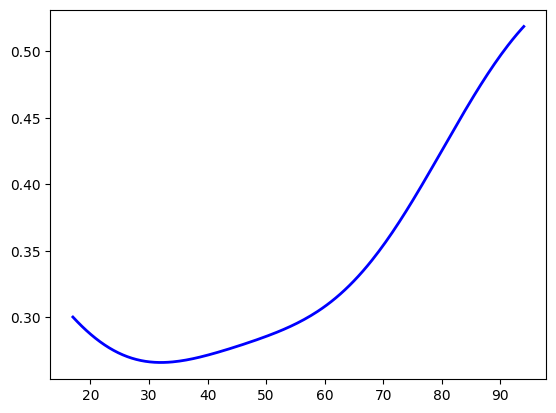

In [ ]:
plt.plot(df_all['x_age'], df_all['y_mean'], label="Mean Prediction", color="blue", linewidth=2)
plt.fill_between(df_all['x_age'].flatten(), ci_lower_range, ci_upper_range, color="blue", alpha=0.3, label="95% Credible Interval")
plt.fill_between(df_all['x_age'].flatten(), pi_lower_orig, pi_upper_orig, color="coral", alpha=0.2, label="95% Predictive Interval")


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_blr_outputs_from_csv(csv_path, feature_name, output_dir=None):
    df = pd.read_csv(csv_path)

    df_train = df[df['set'] == 'train']
    df_test = df[df['set'] == 'test']
    df_mci = df[df['set'] == 'mci']
    df_range = df[df['set'] == 'range']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # --- Plot 1: Train ---
    ax = axes[0]
    ax.scatter(df_train['x_age'], df_train['y_true'], color='orchid', s=10, label='HC Train')
    ax.plot(df_range['x_age'], df_range['y_mean'], color='blue', label='Predicción media')
    ax.set_xlabel('Age')
    ax.set_ylabel('Feature')
    ax.set_title('Predicciones vs Edad (Train)')
    ax.legend()

    # --- Plot 2: Centiles y bandas ---
    ax = axes[1]
    ax.scatter(df_test['x_age'], df_test['y_true'], color='blue', s=10, label='HC')
    ax.scatter(df_mci['x_age'], df_mci['y_true'], color='gray', s=10, label='MCI')
    ax.plot(df_range['x_age'], df_range['y_mean'], color='blue', label='Mean')

    centile_pairs = [(1, 99), (5, 95), (25, 75)]
    colors = ['lightcoral', 'khaki', 'lightblue']
    labels = ['PI', 'CI', 'Q']
    for (low, high), color, label in zip(centile_pairs, colors, labels):
        lo = df_range[f'centile_{low}_low']
        hi = df_range[f'centile_{high}_high']
        ax.fill_between(df_range['x_age'], lo, hi, alpha=0.2, color=color, label=label)
        ax.plot(df_range['x_age'], lo, color='navy', linewidth=0.5)
        ax.plot(df_range['x_age'], hi, color='navy', linewidth=0.5)
    ax.set_title('Bandas de incertidumbre (Test)')
    ax.set_xlabel('Age')
    ax.set_ylabel('Feature')
    ax.legend()

    # --- Plot 3: Histograma Z-scores ---
    ax = axes[2]
    ax.hist(df_test['z_score'], bins=20, color='purple', alpha=0.5, label='HC')
    ax.hist(df_mci['z_score'], bins=20, color='gray', alpha=0.5, label='MCI')
    ax.axvline(0, color='black', linestyle='--')
    ax.set_title('Z-score comparison: HC vs MCI')
    ax.set_xlabel('Z-score')
    ax.set_ylabel('Count')
    ax.legend()

    fig.suptitle(f'BLR outputs for {feature_name}')
    fig.tight_layout()

    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        fig.savefig(os.path.join(output_dir, f'BLR_plot_{feature_name}.png'), dpi=150)

    plt.show()


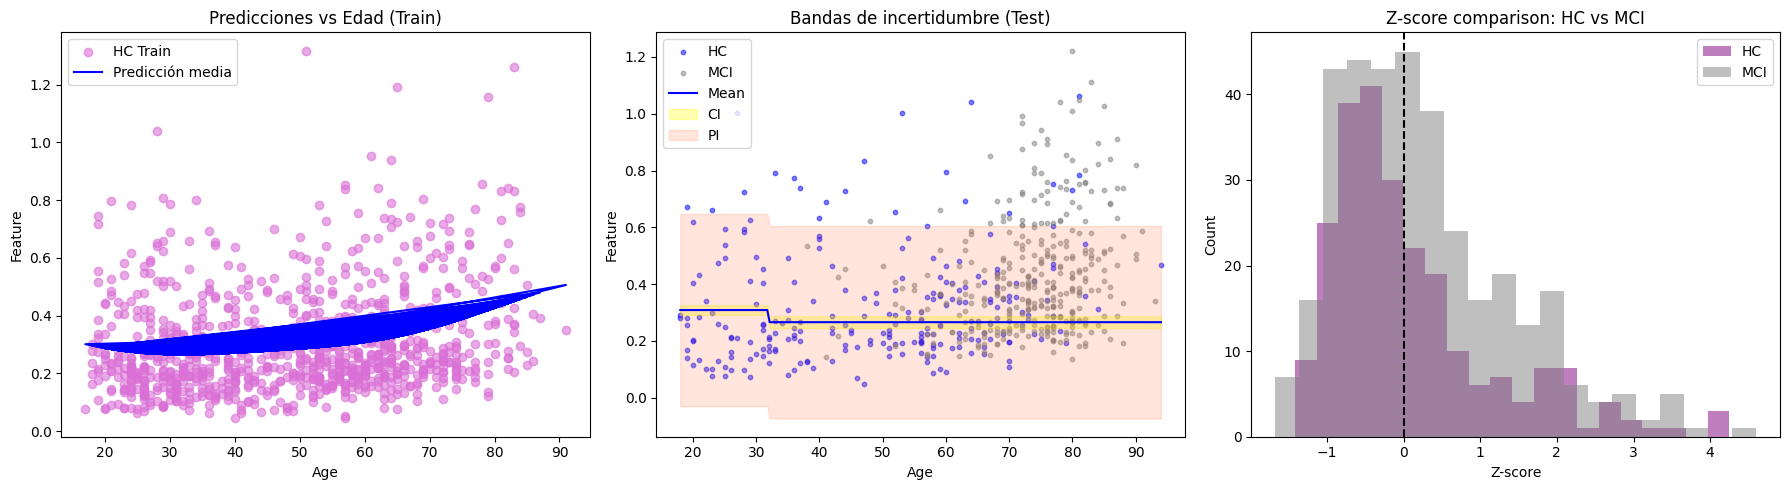

In [25]:
plot_blr_prediction_summary(df_all)

In [31]:
metrics

,feature,msll_train,msll_test,ev_train,ev_test,mse_train,mse_test,rho_train,rho_test
0,harm_osc_pw_ab_canonic_theta_roiC,0.12664,0.14668,0.064062,0.035467,0.029495,0.036401,0.23712,0.189664
